In [ ]:
!pip install gymnasium stable-baselines3 numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 7.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv


def wrap_pi(angle):
    """Wrap angle to (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


class UnicycleTargetEnv(gym.Env):
    """
    Unicycle kinematics with acceleration control:
        x_dot     = v cos(theta)
        y_dot     = v sin(theta)
        theta_dot = omega
        v_dot     = accel

    Actions: [omega, accel]
        omega  -- angular velocity  in [-omega_max,  omega_max]
        accel  -- linear accel      in [-accel_max,  accel_max]
        v is clamped to [v_min, v_max] after each update.

    Observation: [dx, dy, cos(theta), sin(theta), cos(phi), sin(phi),
                  dist, heading_error, v]
      where phi = bearing to target
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=2.5,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.25,
        max_steps=300,
        seed=None,
    ):
        super().__init__()
        self.dt          = float(dt)
        self.v_init      = float(v_init)
        self.v_min       = float(v_min)
        self.v_max       = float(v_max)
        self.omega_max   = float(omega_max)
        self.accel_max   = float(accel_max)
        self.world_size  = float(world_size)
        self.target_radius = float(target_radius)
        self.max_steps   = int(max_steps)

        self.np_random = np.random.default_rng(seed)

        # ---- Action space: [omega, accel] ----
        self.action_space = spaces.Box(
            low=np.array([-self.omega_max, -self.accel_max], dtype=np.float32),
            high=np.array([ self.omega_max,  self.accel_max], dtype=np.float32),
            dtype=np.float32,
        )

        # ---- Observation space (9-dim, adds v) ----
        obs_low = np.array(
            [-2*self.world_size, -2*self.world_size,
             -1, -1, -1, -1,
             0.0, -np.pi,
             self.v_min],
            dtype=np.float32,
        )
        obs_high = np.array(
            [ 2*self.world_size,  2*self.world_size,
              1,  1,  1,  1,
              2*np.sqrt(2)*self.world_size, np.pi,
              self.v_max],
            dtype=np.float32,
        )
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        self.x     = None
        self.y     = None
        self.theta = None
        self.v     = None
        self.tx    = None
        self.ty    = None
        self.steps = 0
        self.prev_dist = None

    def _get_obs(self):
        dx = self.tx - self.x
        dy = self.ty - self.y
        dist = np.sqrt(dx*dx + dy*dy)

        phi           = np.arctan2(dy, dx)          # bearing to target
        heading_error = wrap_pi(phi - self.theta)    # error angle

        obs = np.array(
            [
                dx,
                dy,
                np.cos(self.theta),
                np.sin(self.theta),
                np.cos(phi),
                np.sin(phi),
                dist,
                heading_error,
                self.v,           # <-- new: current speed
            ],
            dtype=np.float32,
        )
        return obs

    def reset(
            self,
            seed=None,
            options=None,
            start=None,
            target=None,
            theta0=None,
            v0=None,
        ):
            super().reset(seed=seed)

            if seed is not None:
                self.np_random = np.random.default_rng(seed)

            # ---- Start position ----
            if start is not None:
                self.x, self.y = start
            else:
                self.x = self.np_random.uniform(-self.world_size, self.world_size)
                self.y = self.np_random.uniform(-self.world_size, self.world_size)

            # ---- Initial heading ----
            if theta0 is not None:
                self.theta = theta0
            else:
                self.theta = self.np_random.uniform(-np.pi, np.pi)

            # ---- Initial speed ----
            if v0 is not None:
                self.v = float(v0)
            else:
                self.v = float(self.v_init)

            # ---- Target position ----
            if target is not None:
                self.tx, self.ty = target
            else:
                for _ in range(100):
                    self.tx = self.np_random.uniform(-self.world_size, self.world_size)
                    self.ty = self.np_random.uniform(-self.world_size, self.world_size)
                    if (self.tx - self.x)**2 + (self.ty - self.y)**2 > (0.5*self.world_size)**2:
                        break

            self.steps = 0
            obs = self._get_obs()
            self.prev_dist = float(obs[6])
            info = {}

            return obs, info

    def step(self, action):
        self.steps += 1

        omega = float(np.clip(action[0], -self.omega_max, self.omega_max))
        accel = float(np.clip(action[1], -self.accel_max,  self.accel_max))

        # --- KINEMATICS UPDATE ---
        # x_{t+1}     = x_t + dt * v * cos(theta)
        # y_{t+1}     = y_t + dt * v * sin(theta)
        # theta_{t+1} = theta_t + dt * omega
        # v_{t+1}     = clamp(v_t + dt * accel, v_min, v_max)
        self.x     += self.dt * self.v * np.cos(self.theta)
        self.y     += self.dt * self.v * np.sin(self.theta)
        self.theta  = wrap_pi(self.theta + self.dt * omega)
        self.v      = float(np.clip(self.v + self.dt * accel,
                                    self.v_min, self.v_max))

        obs           = self._get_obs()
        dist          = float(obs[6])
        heading_error = float(obs[7])

        # --- REWARD SHAPING ---
        # 1) progress reward: distance reduction
        progress = self.prev_dist - dist

        # 2) alignment penalty (encourages turning toward target)
        align_penalty = 0.05 * abs(heading_error)

        # 3) control smoothness penalties
        control_penalty = (
            0.01 * (omega / self.omega_max) ** 2
            + 0.01 * (accel / self.accel_max) ** 2
        )

        reward = 5.0 * progress - align_penalty - control_penalty

        terminated = dist <= self.target_radius
        truncated  = self.steps >= self.max_steps

        if terminated:
            reward += 10.0

        self.prev_dist = dist
        info = {"dist": dist, "heading_error": heading_error,
                "omega": omega, "accel": accel, "v": self.v}
        return obs, reward, terminated, truncated, info


def train():
    env = UnicycleTargetEnv(
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=3.0,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.3,
        max_steps=300,
        seed=0,
    )

    check_env(env, warn=True)

    vec_env = DummyVecEnv([lambda: env])

    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=3e-4,
        ent_coef=0.0,
        clip_range=0.2,
        device="auto",
    )

    model.learn(total_timesteps=300_000)
    model.save("ppo_unicycle_accel")
    print("Saved model to ppo_unicycle_accel.zip")


def test(episodes=5):
    env   = UnicycleTargetEnv(seed=123)
    model = PPO.load("ppo_unicycle_accel")

    for ep in range(episodes):
        obs, _ = env.reset()
        total_r = 0.0
        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            if term or trunc:
                print(f"Episode {ep}: steps={t+1}, success={term}, "
                      f"dist={info['dist']:.3f}, v={info['v']:.2f}, "
                      f"return={total_r:.2f}")
                break


if __name__ == "__main__":
    train()
    test()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetim

-----------------------------
| time/              |      |
|    fps             | 660  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 551          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0065388707 |
|    clip_fraction        | 0.0621       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.85        |
|    explained_variance   | 0.0135       |
|    learning_rate        | 0.0003       |
|    loss                 | 16.6         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00736     |
|    std                  | 1.01         |
|    value_loss           | 41.2         |
----------------

Episode 1: Steps=31, Success=True, Final Distance=0.224, Final v=2.00, Return=33.49


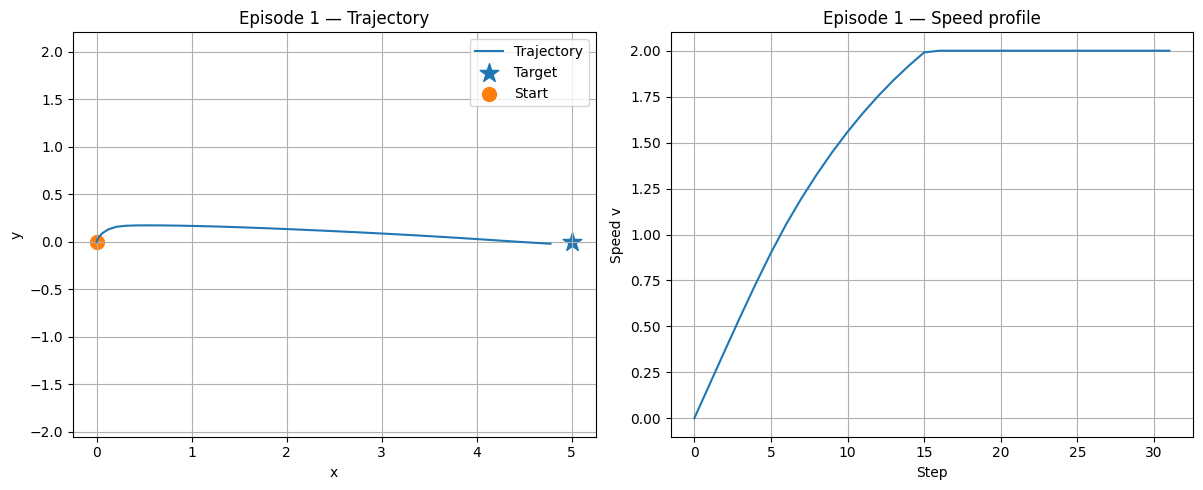

Episode 2: Steps=31, Success=True, Final Distance=0.224, Final v=2.00, Return=33.49


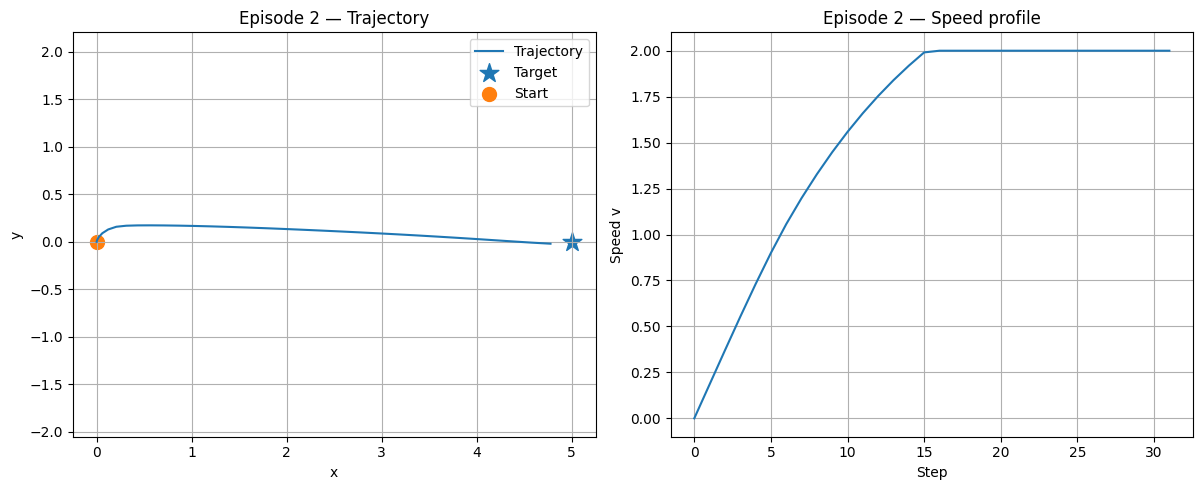

Episode 3: Steps=31, Success=True, Final Distance=0.224, Final v=2.00, Return=33.49


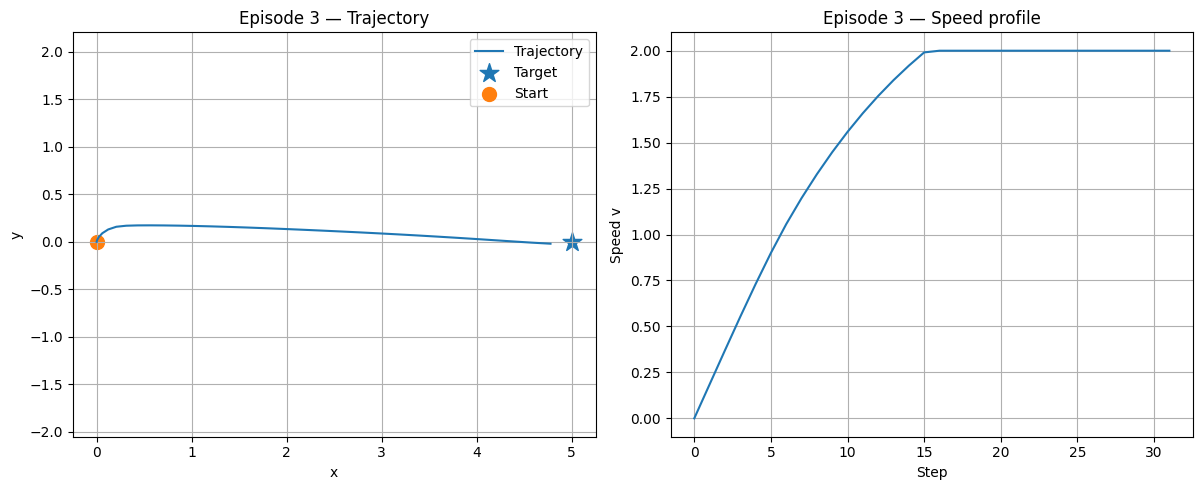

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO


def run_test(model_path="ppo_unicycle_accel.zip", episodes=3):
    model = PPO.load(model_path)
    env   = UnicycleTargetEnv(seed=42)

    for ep in range(episodes):
        obs, _ = env.reset(
            start=(0.0, 0.0),
            target=(5.0, 0.0),
            theta0=np.pi/2,
            v0= 0.0
        )

        xs, ys = [env.x], [env.y]
        vs     = [env.v]
        total_reward = 0

        for step in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            xs.append(env.x)
            ys.append(env.y)
            vs.append(env.v)
            total_reward += reward

            if terminated or truncated:
                break

        print(
            f"Episode {ep+1}: "
            f"Steps={step+1}, "
            f"Success={terminated}, "
            f"Final Distance={info['dist']:.3f}, "
            f"Final v={info['v']:.2f}, "
            f"Return={total_reward:.2f}"
        )

        # -------- Plot trajectory --------
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(xs, ys, label="Trajectory")
        ax1.scatter(env.tx, env.ty, marker="*", s=200, label="Target")
        ax1.scatter(xs[0], ys[0], marker="o", s=100, label="Start")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_title(f"Episode {ep+1} — Trajectory")
        ax1.legend()
        ax1.axis("equal")
        ax1.grid()

        ax2.plot(vs)
        ax2.set_xlabel("Step")
        ax2.set_ylabel("Speed v")
        ax2.set_title(f"Episode {ep+1} — Speed profile")
        ax2.set_ylim(env.v_min - 0.1, env.v_max + 0.1)
        ax2.grid()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    run_test()

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv


def wrap_pi(angle):
    """Wrap angle to (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


class UnicycleTargetEnv(gym.Env):
    """
    Unicycle kinematics with acceleration control:
        x_dot     = v cos(theta)
        y_dot     = v sin(theta)
        theta_dot = omega
        v_dot     = accel

    Actions: [omega, accel]
        omega  -- angular velocity  in [-omega_max,  omega_max]
        accel  -- linear accel      in [-accel_max,  accel_max]
        v is clamped to [v_min, v_max] after each update.

    Observation: [dx, dy, cos(theta), sin(theta), cos(phi), sin(phi),
                  dist, heading_error, v]
      where phi = bearing to target
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=2.5,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.25,
        max_steps=300,
        seed=None,
    ):
        super().__init__()
        self.dt          = float(dt)
        self.v_init      = float(v_init)
        self.v_min       = float(v_min)
        self.v_max       = float(v_max)
        self.omega_max   = float(omega_max)
        self.accel_max   = float(accel_max)
        self.world_size  = float(world_size)
        self.target_radius = float(target_radius)
        self.max_steps   = int(max_steps)

        self.np_random = np.random.default_rng(seed)

        # ---- Action space: [omega, accel] ----
        self.action_space = spaces.Box(
            low=np.array([-self.omega_max, -self.accel_max], dtype=np.float32),
            high=np.array([ self.omega_max,  self.accel_max], dtype=np.float32),
            dtype=np.float32,
        )

        # ---- Observation space (9-dim, adds v) ----
        obs_low = np.array(
            [-2*self.world_size, -2*self.world_size,
             -1, -1, -1, -1,
             0.0, -np.pi,
             self.v_min],
            dtype=np.float32,
        )
        obs_high = np.array(
            [ 2*self.world_size,  2*self.world_size,
              1,  1,  1,  1,
              2*np.sqrt(2)*self.world_size, np.pi,
              self.v_max],
            dtype=np.float32,
        )
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        self.x     = None
        self.y     = None
        self.theta = None
        self.v     = None
        self.tx    = None
        self.ty    = None
        self.steps = 0
        self.prev_dist = None

    def _get_obs(self):
        dx = self.tx - self.x
        dy = self.ty - self.y
        dist = np.sqrt(dx*dx + dy*dy)

        phi           = np.arctan2(dy, dx)          # bearing to target
        heading_error = wrap_pi(phi - self.theta)    # error angle

        obs = np.array(
            [
                dx,
                dy,
                np.cos(self.theta),
                np.sin(self.theta),
                np.cos(phi),
                np.sin(phi),
                dist,
                heading_error,
                self.v,           # <-- new: current speed
            ],
            dtype=np.float32,
        )
        return obs

    def reset(
            self,
            seed=None,
            options=None,
            start=None,
            target=None,
            theta0=None,
            v0=None,
        ):
            super().reset(seed=seed)

            if seed is not None:
                self.np_random = np.random.default_rng(seed)

            # ---- Start position ----
            if start is not None:
                self.x, self.y = start
            else:
                self.x = self.np_random.uniform(-self.world_size, self.world_size)
                self.y = self.np_random.uniform(-self.world_size, self.world_size)

            # ---- Initial heading ----
            if theta0 is not None:
                self.theta = theta0
            else:
                self.theta = self.np_random.uniform(-np.pi, np.pi)

            # ---- Initial speed ----
            if v0 is not None:
                self.v = float(v0)
            else:
                self.v = float(self.v_init)

            # ---- Target position ----
            if target is not None:
                self.tx, self.ty = target
            else:
                for _ in range(100):
                    self.tx = self.np_random.uniform(-self.world_size, self.world_size)
                    self.ty = self.np_random.uniform(-self.world_size, self.world_size)
                    if (self.tx - self.x)**2 + (self.ty - self.y)**2 > (0.5*self.world_size)**2:
                        break

            self.steps = 0
            obs = self._get_obs()
            self.prev_dist = float(obs[6])
            info = {}

            return obs, info

    def step(self, action):
        self.steps += 1

        omega = float(np.clip(action[0], -self.omega_max, self.omega_max))
        accel = float(np.clip(action[1], -self.accel_max,  self.accel_max))

        # --- KINEMATICS UPDATE ---
        # x_{t+1}     = x_t + dt * v * cos(theta)
        # y_{t+1}     = y_t + dt * v * sin(theta)
        # theta_{t+1} = theta_t + dt * omega
        # v_{t+1}     = clamp(v_t + dt * accel, v_min, v_max)
        self.x     += self.dt * self.v * np.cos(self.theta)
        self.y     += self.dt * self.v * np.sin(self.theta)
        self.theta  = wrap_pi(self.theta + self.dt * omega)
        self.v      = float(np.clip(self.v + self.dt * accel,
                                    self.v_min, self.v_max))

        obs           = self._get_obs()
        dist          = float(obs[6])
        heading_error = float(obs[7])

        # --- REWARD SHAPING ---
        # 1) progress reward: distance reduction
        progress = self.prev_dist - dist

        # 2) alignment penalty (encourages turning toward target)
        align_penalty = 0.05 * abs(heading_error)

        # 3) control smoothness penalties
        control_penalty = (
            0.01 * (omega / self.omega_max) ** 2
            + 0.01 * (accel / self.accel_max) ** 2
        )

        reward = 0.05 * progress - 5.0 * align_penalty - control_penalty

        terminated = dist <= self.target_radius
        truncated  = self.steps >= self.max_steps

        if terminated:
            reward += 10.0

        self.prev_dist = dist
        info = {"dist": dist, "heading_error": heading_error,
                "omega": omega, "accel": accel, "v": self.v}
        return obs, reward, terminated, truncated, info


def train():
    env = UnicycleTargetEnv(
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=3.0,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.3,
        max_steps=300,
        seed=0,
    )

    check_env(env, warn=True)

    vec_env = DummyVecEnv([lambda: env])

    model2 = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=3e-4,
        ent_coef=0.0,
        clip_range=0.2,
        device="auto",
    )

    model2.learn(total_timesteps=300_000)
    model2.save("ppo_unicycle_accel2")
    print("Saved model 2 to ppo_unicycle_accel2.zip")


def test(episodes=5):
    env   = UnicycleTargetEnv(seed=123)
    model = PPO.load("ppo_unicycle_accel2")

    for ep in range(episodes):
        obs, _ = env.reset()
        total_r = 0.0
        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            if term or trunc:
                print(f"Episode {ep}: steps={t+1}, success={term}, "
                      f"dist={info['dist']:.3f}, v={info['v']:.2f}, "
                      f"return={total_r:.2f}")
                break


if __name__ == "__main__":
    train()
    test()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:515: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cuda device
-----------------------------
| time/              |      |
|    fps             | 303  |
|    iterations      | 1    |
|    time_elapsed    | 6    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 354          |
|    iterations           | 2            |
|    time_elapsed         | 11           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0057369294 |
|    clip_fraction        | 0.0405       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.83        |
|    explained_variance   | 0.0508       |
|    learning_rate        | 0.0003       |
|    loss                 | 12           |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0065      |
|    std                  | 0.993        |
|    value_loss           | 46.3         

Episode 1: Steps=28, Success=True, Final Distance=0.115, Final v=1.93, Return=8.93


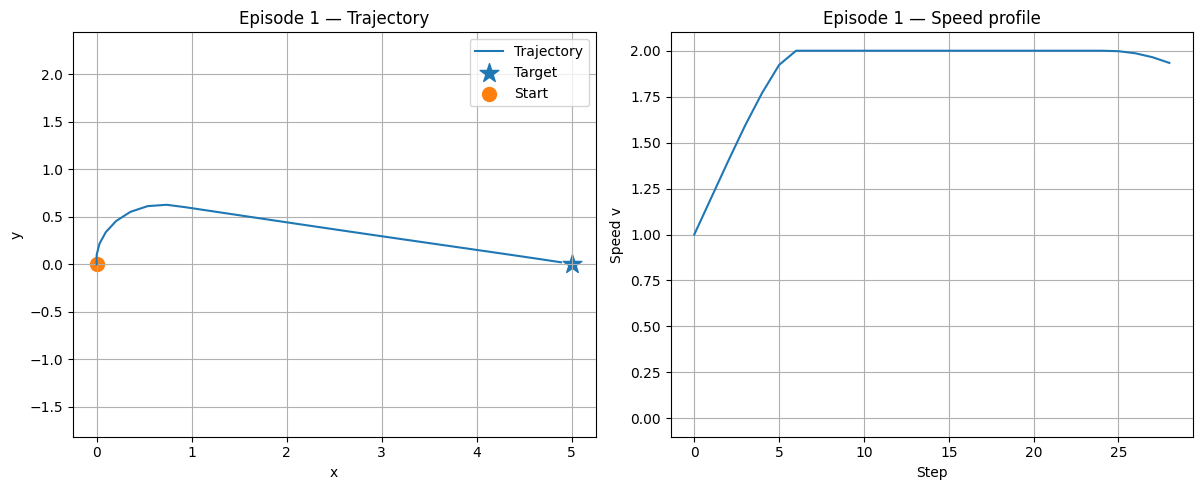

Episode 2: Steps=28, Success=True, Final Distance=0.115, Final v=1.93, Return=8.93


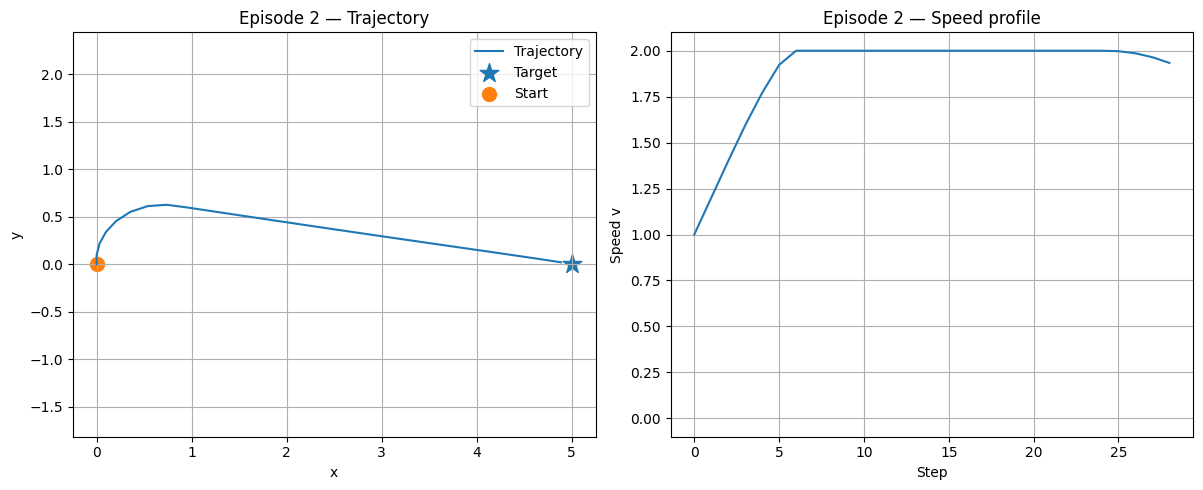

Episode 3: Steps=28, Success=True, Final Distance=0.115, Final v=1.93, Return=8.93


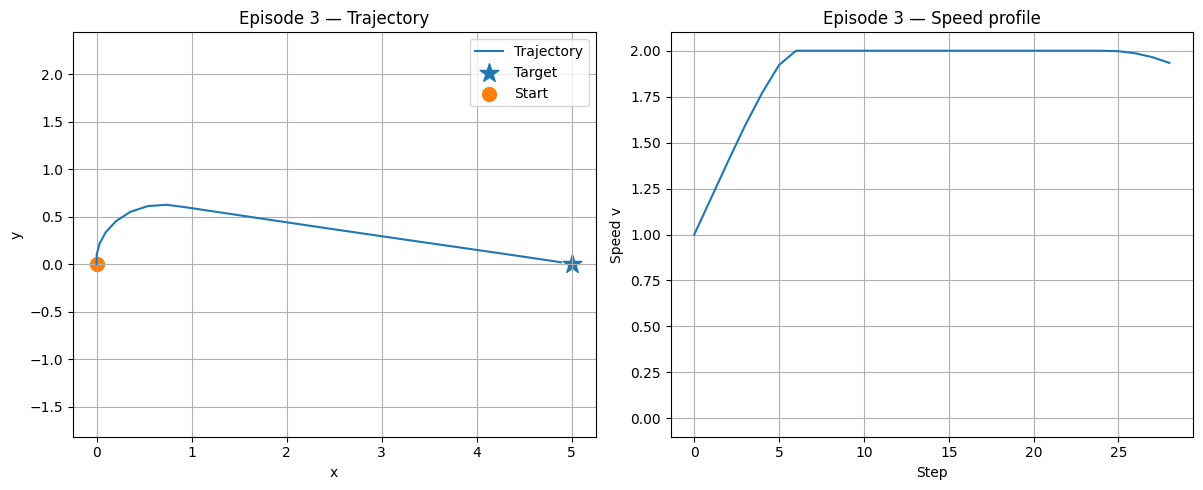

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO


def run_test(model_path="ppo_unicycle_accel2.zip", episodes=3):
    model = PPO.load(model_path)
    env   = UnicycleTargetEnv(seed=42)

    for ep in range(episodes):
        obs, _ = env.reset(
            start=(0.0, 0.0),
            target=(5.0, 0.0),
            theta0=np.pi/2,
            v0= 1.0
        )

        xs, ys = [env.x], [env.y]
        vs     = [env.v]
        total_reward = 0

        for step in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            xs.append(env.x)
            ys.append(env.y)
            vs.append(env.v)
            total_reward += reward

            if terminated or truncated:
                break

        print(
            f"Episode {ep+1}: "
            f"Steps={step+1}, "
            f"Success={terminated}, "
            f"Final Distance={info['dist']:.3f}, "
            f"Final v={info['v']:.2f}, "
            f"Return={total_reward:.2f}"
        )

        # -------- Plot trajectory --------
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        ax1.plot(xs, ys, label="Trajectory")
        ax1.scatter(env.tx, env.ty, marker="*", s=200, label="Target")
        ax1.scatter(xs[0], ys[0], marker="o", s=100, label="Start")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.set_title(f"Episode {ep+1} — Trajectory")
        ax1.legend()
        ax1.axis("equal")
        ax1.grid()

        ax2.plot(vs)
        ax2.set_xlabel("Step")
        ax2.set_ylabel("Speed v")
        ax2.set_title(f"Episode {ep+1} — Speed profile")
        ax2.set_ylim(env.v_min - 0.1, env.v_max + 0.1)
        ax2.grid()

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    run_test()

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv


def wrap_pi(angle):
    """Wrap angle to (-pi, pi]."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def ray_circle_intersect(ox, oy, dx, dy, cx, cy, radius):
    """
    Returns distance along ray (origin ox,oy, unit direction dx,dy)
    to the nearest intersection with circle (cx,cy,radius).
    Returns np.inf if no intersection.
    """
    fx = ox - cx
    fy = oy - cy
    a = dx*dx + dy*dy          # = 1 if direction is unit vector
    b = 2 * (fx*dx + fy*dy)
    c = fx*fx + fy*fy - radius*radius
    disc = b*b - 4*a*c
    if disc < 0:
        return np.inf
    sqrt_disc = np.sqrt(disc)
    t1 = (-b - sqrt_disc) / (2*a)
    t2 = (-b + sqrt_disc) / (2*a)
    # We want smallest positive t
    t = np.inf
    if t1 > 1e-6:
        t = t1
    if t2 > 1e-6 and t2 < t:
        t = t2
    return t


class UnicycleObstacleEnv(gym.Env):
    """
    Unicycle kinematics with acceleration control + circular obstacles.

    Observation (9 base + N_RAYS lidar):
        [dx, dy, cos(theta), sin(theta), cos(phi), sin(phi),
         dist, heading_error, v,
         lidar_0, lidar_1, ..., lidar_{N_RAYS-1}]

    Lidar rays are cast uniformly around the agent in the agent's
    world frame. Each reading is the normalised distance to the nearest
    obstacle (0 = touching, 1 = at max lidar range or beyond).

    Actions: [omega, accel]
        omega -- angular velocity in [-omega_max, omega_max]
        accel -- linear accel    in [-accel_max, accel_max]
        v is clamped to [v_min, v_max].

    Obstacle format: list of (cx, cy, radius) tuples.

    Training: obstacles are randomly generated every reset().
    Testing:  pass obstacles=[(cx,cy,r), ...] to reset() to fix the course.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=2.5,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.25,
        max_steps=400,
        # --- obstacle settings ---
        n_obstacles_range=(2, 6),       # random number of obstacles per episode
        obs_radius_range=(0.3, 1.2),    # random radius of each obstacle
        min_obs_clearance=0.5,          # min gap between obstacle edge and agent/target
        # --- lidar settings ---
        n_rays=16,                      # number of lidar rays (fixed at train time)
        lidar_range=8.0,                # max sensing distance
        collision_penalty=20.0,         # penalty for hitting an obstacle
        seed=None,
    ):
        super().__init__()

        self.dt             = float(dt)
        self.v_init         = float(v_init)
        self.v_min          = float(v_min)
        self.v_max          = float(v_max)
        self.omega_max      = float(omega_max)
        self.accel_max      = float(accel_max)
        self.world_size     = float(world_size)
        self.target_radius  = float(target_radius)
        self.max_steps      = int(max_steps)

        self.n_obstacles_range  = n_obstacles_range
        self.obs_radius_range   = obs_radius_range
        self.min_obs_clearance  = float(min_obs_clearance)

        self.n_rays          = int(n_rays)
        self.lidar_range     = float(lidar_range)
        self.collision_penalty = float(collision_penalty)

        self.np_random = np.random.default_rng(seed)

        # ---- Action space ----
        self.action_space = spaces.Box(
            low=np.array([-self.omega_max, -self.accel_max], dtype=np.float32),
            high=np.array([ self.omega_max,  self.accel_max], dtype=np.float32),
            dtype=np.float32,
        )

        # ---- Observation space: 9 base + n_rays lidar ----
        n_obs = 9 + self.n_rays
        obs_low  = np.full(n_obs, -np.inf, dtype=np.float32)
        obs_high = np.full(n_obs,  np.inf, dtype=np.float32)

        # base dims
        obs_low[:9]  = [-2*self.world_size, -2*self.world_size,
                         -1, -1, -1, -1,
                          0.0, -np.pi, self.v_min]
        obs_high[:9] = [ 2*self.world_size,  2*self.world_size,
                          1,  1,  1,  1,
                          2*np.sqrt(2)*self.world_size, np.pi, self.v_max]
        # lidar dims: normalised [0, 1]
        obs_low[9:]  = 0.0
        obs_high[9:] = 1.0

        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

        # state
        self.x         = None
        self.y         = None
        self.theta     = None
        self.v         = None
        self.tx        = None
        self.ty        = None
        self.obstacles = []   # list of (cx, cy, r)
        self.steps     = 0
        self.prev_dist = None

    # ------------------------------------------------------------------
    # Lidar
    # ------------------------------------------------------------------
    def _cast_lidar(self):
        """Cast n_rays uniformly in world frame, return normalised readings."""
        readings = np.ones(self.n_rays, dtype=np.float32)   # 1 = nothing in range
        if not self.obstacles:
            return readings

        angles = np.linspace(0, 2*np.pi, self.n_rays, endpoint=False)
        for i, angle in enumerate(angles):
            dx = np.cos(angle)
            dy = np.sin(angle)
            min_dist = self.lidar_range
            for (cx, cy, r) in self.obstacles:
                t = ray_circle_intersect(self.x, self.y, dx, dy, cx, cy, r)
                if t < min_dist:
                    min_dist = t
            readings[i] = float(np.clip(min_dist / self.lidar_range, 0.0, 1.0))
        return readings

    # ------------------------------------------------------------------
    # Collision check
    # ------------------------------------------------------------------
    def _in_collision(self):
        for (cx, cy, r) in self.obstacles:
            dist_sq = (self.x - cx)**2 + (self.y - cy)**2
            if dist_sq <= r**2:
                return True
        return False

    # ------------------------------------------------------------------
    # Observation
    # ------------------------------------------------------------------
    def _get_obs(self):
        dx   = self.tx - self.x
        dy   = self.ty - self.y
        dist = np.sqrt(dx*dx + dy*dy)

        phi           = np.arctan2(dy, dx)
        heading_error = wrap_pi(phi - self.theta)

        base = np.array(
            [dx, dy,
             np.cos(self.theta), np.sin(self.theta),
             np.cos(phi),        np.sin(phi),
             dist, heading_error,
             self.v],
            dtype=np.float32,
        )
        lidar = self._cast_lidar()
        return np.concatenate([base, lidar])

    # ------------------------------------------------------------------
    # Obstacle generation (training)
    # ------------------------------------------------------------------
    def _generate_obstacles(self, n_obs):
        """
        Randomly place n_obs circular obstacles that do not overlap
        the start position, target, or each other.
        Returns list of (cx, cy, radius).
        """
        obstacles = []
        clearance = self.min_obs_clearance
        max_tries = 200

        for _ in range(n_obs):
            for _ in range(max_tries):
                r  = self.np_random.uniform(*self.obs_radius_range)
                cx = self.np_random.uniform(-self.world_size + r,
                                             self.world_size - r)
                cy = self.np_random.uniform(-self.world_size + r,
                                             self.world_size - r)

                # clear of agent start
                if (cx - self.x)**2 + (cy - self.y)**2 < (r + clearance)**2:
                    continue
                # clear of target
                if (cx - self.tx)**2 + (cy - self.ty)**2 < (r + clearance)**2:
                    continue
                # clear of other obstacles
                ok = True
                for (ex, ey, er) in obstacles:
                    if (cx-ex)**2 + (cy-ey)**2 < (r + er + clearance)**2:
                        ok = False
                        break
                if not ok:
                    continue

                obstacles.append((cx, cy, r))
                break   # placed successfully

        return obstacles

    # ------------------------------------------------------------------
    # reset
    # ------------------------------------------------------------------
    def reset(
        self,
        seed=None,
        options=None,
        start=None,
        target=None,
        theta0=None,
        v0=None,
        obstacles=None,         # list of (cx, cy, r) — set at test time
        n_obstacles=None,       # override random count at train time
    ):
        super().reset(seed=seed)
        if seed is not None:
            self.np_random = np.random.default_rng(seed)

        # ---- Start ----
        if start is not None:
            self.x, self.y = float(start[0]), float(start[1])
        else:
            self.x = self.np_random.uniform(-self.world_size, self.world_size)
            self.y = self.np_random.uniform(-self.world_size, self.world_size)

        # ---- Heading ----
        self.theta = float(theta0) if theta0 is not None else \
                     self.np_random.uniform(-np.pi, np.pi)

        # ---- Speed ----
        self.v = float(v0) if v0 is not None else float(self.v_init)

        # ---- Target ----
        if target is not None:
            self.tx, self.ty = float(target[0]), float(target[1])
        else:
            for _ in range(200):
                self.tx = self.np_random.uniform(-self.world_size, self.world_size)
                self.ty = self.np_random.uniform(-self.world_size, self.world_size)
                if (self.tx-self.x)**2 + (self.ty-self.y)**2 > (0.5*self.world_size)**2:
                    break

        # ---- Obstacles ----
        if obstacles is not None:
            # test-time: use exactly what the user provided
            self.obstacles = [(float(cx), float(cy), float(r))
                              for (cx, cy, r) in obstacles]
        else:
            # training: random course
            n = n_obstacles if n_obstacles is not None else \
                int(self.np_random.integers(*self.n_obstacles_range))
            self.obstacles = self._generate_obstacles(n)

        self.steps = 0
        obs = self._get_obs()
        self.prev_dist = float(obs[6])
        return obs, {}

    # ------------------------------------------------------------------
    # step
    # ------------------------------------------------------------------
    # def step(self, action):
    #     self.steps += 1

    #     omega = float(np.clip(action[0], -self.omega_max, self.omega_max))
    #     accel = float(np.clip(action[1], -self.accel_max,  self.accel_max))

    #     self.x     += self.dt * self.v * np.cos(self.theta)
    #     self.y     += self.dt * self.v * np.sin(self.theta)
    #     self.theta  = wrap_pi(self.theta + self.dt * omega)
    #     self.v      = float(np.clip(self.v + self.dt * accel,
    #                                 self.v_min, self.v_max))

    #     obs           = self._get_obs()
    #     dist          = float(obs[6])
    #     heading_error = float(obs[7])
    #     lidar         = obs[9:]                       # normalised [0,1]

    #     # --- REWARD ---
    #     # 1) progress
    #     progress = self.prev_dist - dist
    #     # 2) alignment
    #     align_penalty = 0.05 * abs(heading_error)
    #     # 3) control smoothness
    #     control_penalty = (0.01 * (omega / self.omega_max)**2
    #                      + 0.01 * (accel / self.accel_max)**2)
    #     # 4) proximity warning: penalise being very close to any obstacle
    #     #    lidar reading of 0 = touching, 1 = far away
    #     min_lidar = float(lidar.min()) if len(self.obstacles) > 0 else 1.0
    #     #proximity_penalty = 0.2 * max(0.0, 0.3 - min_lidar)   # kicks in inside 30% of lidar range
    #     proximity_penalty = 0.5 * max(0.0, 0.5 - min_lidar)

    #     # reward = (5.0 * progress
    #     #           - align_penalty
    #     #           - control_penalty
    #     #           - proximity_penalty)

    #     reward = (5.0 * progress
    #       - control_penalty
    #       - proximity_penalty)

    #     # 5) collision
    #     collided = self._in_collision()
    #     if collided:
    #         reward -= self.collision_penalty

    #     terminated = dist <= self.target_radius or collided
    #     truncated  = self.steps >= self.max_steps

    #     if dist <= self.target_radius:
    #         reward += 10.0

    #     self.prev_dist = dist
    #     info = {
    #         "dist": dist,
    #         "heading_error": heading_error,
    #         "omega": omega,
    #         "accel": accel,
    #         "v": self.v,
    #         "collided": collided,
    #         "min_lidar": min_lidar,
    #     }
    #     return obs, reward, terminated, truncated, info

    def step(self, action):
      self.steps += 1

      omega = float(np.clip(action[0], -self.omega_max, self.omega_max))
      accel = float(np.clip(action[1], -self.accel_max,  self.accel_max))

      # --- KINEMATICS UPDATE ---
      self.x     += self.dt * self.v * np.cos(self.theta)
      self.y     += self.dt * self.v * np.sin(self.theta)
      self.theta  = wrap_pi(self.theta + self.dt * omega)
      self.v      = float(np.clip(self.v + self.dt * accel,
                                  self.v_min, self.v_max))

      obs           = self._get_obs()
      dist          = float(obs[6])
      heading_error = float(obs[7])
      lidar         = obs[9:]

      # --- REWARD SHAPING ---
      # progress  = self.prev_dist - dist
      # min_lidar = float(lidar.min()) if len(self.obstacles) > 0 else 1.0

      # # 1) progress weight drops when obstacle is close
      # danger          = max(0.0, 1.0 - (min_lidar / 0.4))
      # progress_weight = 5.0 * (1.0 - 0.8 * danger)

      # # 2) proximity penalty - stronger and wider
      # proximity_penalty = 2.0 * max(0.0, 0.6 - min_lidar)

      # # 3) control smoothness
      # control_penalty = (
      #     0.01 * (omega / self.omega_max) ** 2
      #     + 0.01 * (accel / self.accel_max) ** 2
      # )

      # # 4) gentle reward for staying in open space
      # safety_reward = 0.1 * min_lidar

      # reward = (progress_weight * progress
      #           - proximity_penalty
      #           - control_penalty
      #           + safety_reward)

      # # 5) collision
      # collided = self._in_collision()
      # if collided:
      #     reward -= self.collision_penalty

      progress  = self.prev_dist - dist
      min_lidar = float(lidar.min()) if len(self.obstacles) > 0 else 1.0

      # progress completely suppressed when obstacle is close
      danger          = max(0.0, 1.0 - (min_lidar / 0.5))
      progress_weight = 5.0 * (1.0 - danger)

      # proximity penalty
      proximity_penalty = 4.0 * max(0.0, 0.6 - min_lidar)

      # near miss
      near_miss_penalty = 5.0 if min_lidar < 0.15 else 0.0

      # control smoothness — omega penalty reduced so sharp turns are cheaper
      control_penalty = (
          0.001 * (omega / self.omega_max) ** 2    # was 0.01 — sharp turns now almost free
          + 0.01 * (accel / self.accel_max) ** 2
      )

      # open space reward
      safety_reward = 0.1 * min_lidar

      reward = (progress_weight * progress
                - proximity_penalty
                - near_miss_penalty
                - control_penalty
                + safety_reward)

      # collision — massive penalty, way bigger than any progress gain
      collided = self._in_collision()
      if collided:
          reward -= self.collision_penalty     # keep this at 50.0 in __init__

      terminated = dist <= self.target_radius or collided
      truncated  = self.steps >= self.max_steps

      if dist <= self.target_radius:
          reward += 10.0

      self.prev_dist = dist
      info = {"dist": dist, "heading_error": heading_error,
              "omega": omega, "accel": accel, "v": self.v,
              "collided": collided, "min_lidar": min_lidar}
      return obs, reward, terminated, truncated, info


# ===========================================================================
# TRAIN
# ===========================================================================
def train():
    env = UnicycleObstacleEnv(
        dt=0.1,
        v_init=1.0,
        v_min=0.0,
        v_max=2.0,
        omega_max=3.0,
        accel_max=2.0,
        world_size=10.0,
        target_radius=0.3,
        max_steps=400,
        n_obstacles_range=(2, 6),       # 2-6 random obstacles per episode
        obs_radius_range=(0.3, 1.2),
        min_obs_clearance=0.5,
        n_rays=16,
        lidar_range=5.0,
        collision_penalty=50.0,
        seed=0,
    )

    check_env(env, warn=True)
    vec_env = DummyVecEnv([lambda: env])

    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        n_steps=2048,
        batch_size=256,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=3e-4,
        ent_coef=0.01,          # slight entropy bonus helps explore around obstacles
        clip_range=0.2,
        device="auto",
    )

    model.learn(total_timesteps= 1_000_000)   # more steps needed for obstacle avoidance
    model.save("ppo_unicycle_obstacles")
    print("Saved model to ppo_unicycle_obstacles.zip")


# ===========================================================================
# TEST  —  user defines the exact obstacle course
# ===========================================================================
def test(episodes=5):
    """
    At test time you can pass any obstacle course you like.
    Each obstacle: (center_x, center_y, radius)
    """
    env   = UnicycleObstacleEnv(n_rays=16, lidar_range=5.0)
    model = PPO.load("ppo_unicycle_obstacles")

    # ---- Define your obstacle course here ----
    user_obstacles = [
        (2.5,  0.3, 0.6),
        (4.0, -0.5, 0.8),
        (1.0,  1.5, 0.5),
    ]

    for ep in range(episodes):
        obs, _ = env.reset(
            start=(0.0, 0.0),
            target=(5.0, 0.0),
            theta0=np.pi / 2,
            v0=0.0,
            obstacles=user_obstacles,   # <-- fixed test course
        )

        total_r = 0.0
        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            if term or trunc:
                status = "REACHED" if info["dist"] <= env.target_radius else \
                         "COLLIDED" if info["collided"] else "TIMEOUT"
                print(f"Episode {ep+1}: steps={t+1}, status={status}, "
                      f"dist={info['dist']:.3f}, v={info['v']:.2f}, "
                      f"return={total_r:.2f}")
                break


if __name__ == "__main__":
    train()
    test()

Using cuda device
-----------------------------
| time/              |      |
|    fps             | 632  |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 563          |
|    iterations           | 2            |
|    time_elapsed         | 7            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044391495 |
|    clip_fraction        | 0.0351       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.0301       |
|    learning_rate        | 0.0003       |
|    loss                 | 36.7         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00332     |
|    std                  | 1            |
|    value_loss           | 55.8         

In [ ]:
 import matplotlib.pyplot as plt
import numpy as np
def test(episodes=5):
    env   = UnicycleObstacleEnv(n_rays=16, lidar_range=5.0)
    model = PPO.load("ppo_unicycle_obstacles")

    # ---- Define your obstacle course here ----
    # Format: (center_x, center_y, radius)
    user_obstacles = [
        (2.5,  0.3, 0.6),
        (4.0, -0.5, 0.8),
        (1.0,  1.5, 0.5),
    ]

    for ep in range(episodes):
        obs, _ = env.reset(
            start=(0.0, 0.0),
            target=(5.0, 0.0),
            theta0=np.pi / 2,
            v0=0.0,
            obstacles=user_obstacles,
        )

        total_r = 0.0
        path = [(env.x, env.y)]   # track path for plotting

        for t in range(env.max_steps):
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(action)
            total_r += r
            path.append((env.x, env.y))

            if term or trunc:
                status = "REACHED"  if info["dist"] <= env.target_radius else \
                         "COLLIDED" if info["collided"] else "TIMEOUT"
                print(f"Episode {ep+1}: steps={t+1}, status={status}, "
                      f"dist={info['dist']:.3f}, v={info['v']:.2f}, "
                      f"return={total_r:.2f}")
                break

        # ---- Plot the path ----
        path = np.array(path)
        fig, ax = plt.subplots(figsize=(7, 7))

        # obstacles
        for (cx, cy, r) in user_obstacles:
            circle = plt.Circle((cx, cy), r, color="gray", alpha=0.5)
            ax.add_patch(circle)

        # path
        ax.plot(path[:, 0], path[:, 1], "b-", linewidth=1.5, label="path")

        # start and target
        ax.plot(0, 0, "o", color="orange", markersize=10, label="start")
        ax.plot(5, 0, "*", color="blue",   markersize=14, label="target")

        ax.set_xlim(-2, 8)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.grid(True)
        ax.legend()
        ax.set_title(f"Episode {ep+1} — {status}")
        plt.tight_layout()
        plt.show()

test()